# Shelter Categories Demo

In [1]:
import rioxarray as rxr

from shelterbelts.utils.filepaths import get_filename
from shelterbelts.utils.visualisation import visualise_categories_sidebyside, visualise_categories
from shelterbelts.indices.shelter_categories import shelter_categories
from shelterbelts.indices.shelter_categories import shelter_categories_cmap, shelter_categories_labels

# Example data
linear_categories_file = get_filename('g2_26729_linear_categories.tif')
wind_file = get_filename('g2_26729_barra_daily.nc')
height_file = get_filename('g2_26729_chm_res10_filled.tif')

In [2]:
# Load the linear categories generated by demo_shelter_metrics.py (shelter_categories now runs last,
# on the full tree classification, so sheltered farmland can be attributed to the sheltering tree type)
da_linear = rxr.open_rasterio(linear_categories_file).isel(band=0).drop_vars('band')
ds_linear = da_linear.to_dataset(name='linear_categories')

## Default Parameters
The default location is a ~2km x 2km region near Milgadara, NSW, Australia. 

Saved: ./TEST_shelter_categories.tif
Saved: ./TEST_shelter_densities.tif
Saved: ./TEST_shelter_categories.png


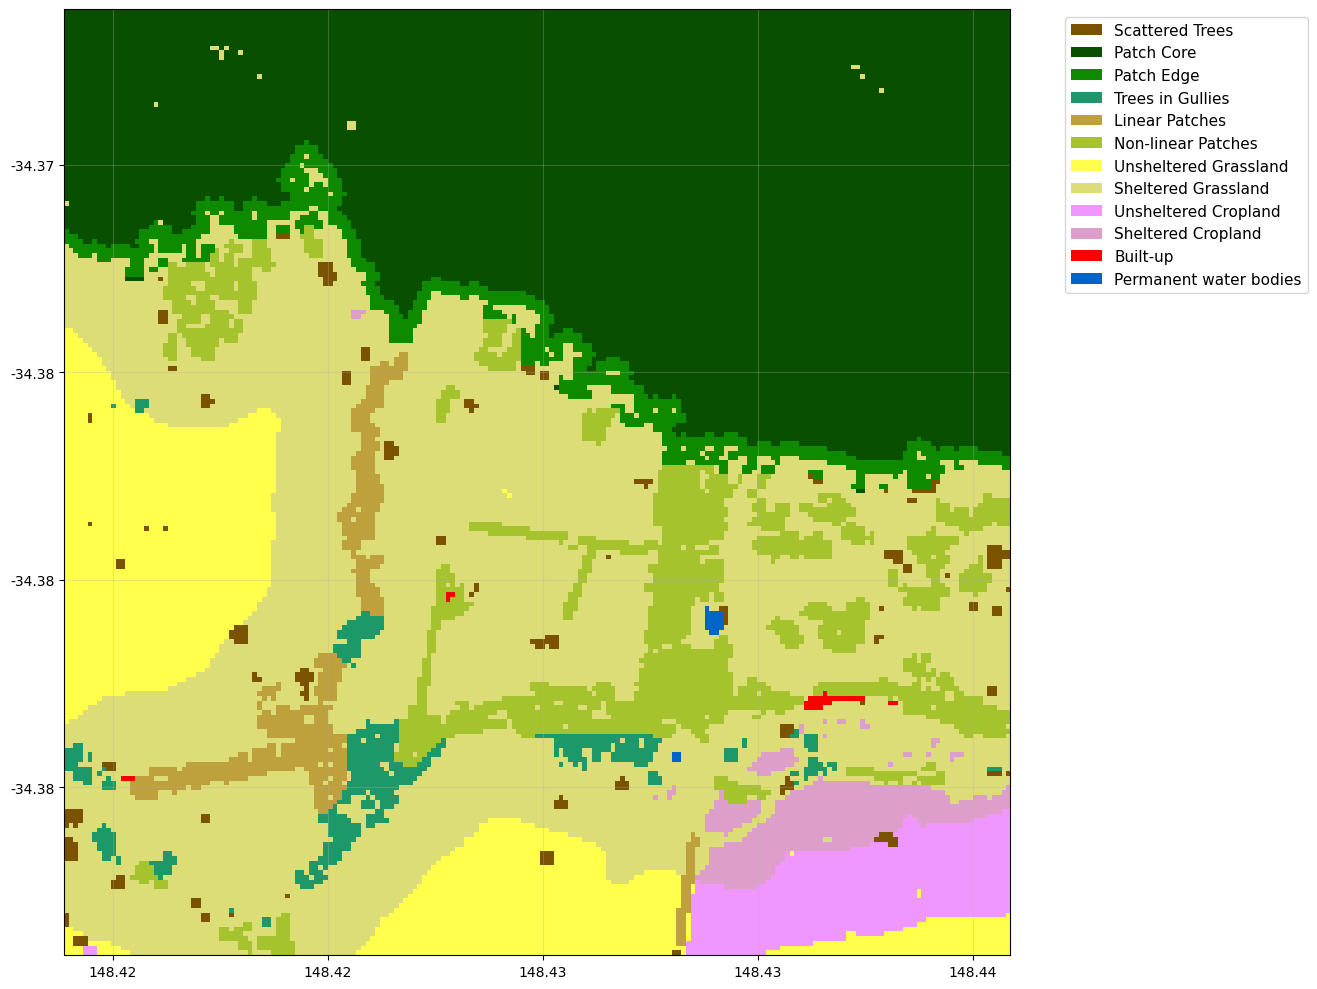

In [3]:
ds_default = shelter_categories(ds_linear)
visualise_categories(
    ds_default['shelter_categories'],
    colormap=shelter_categories_cmap,
    labels=shelter_categories_labels
)

## Changing the density_threshold

The `density_threshold` parameter sets the minimum percentage tree cover (within a radius) that counts as sheltered.

Saved: ./density3_shelter_categories.tif
Saved: ./density3_shelter_densities.tif
Saved: ./density3_shelter_categories.png
Saved: ./density10_shelter_categories.tif
Saved: ./density10_shelter_densities.tif
Saved: ./density10_shelter_categories.png


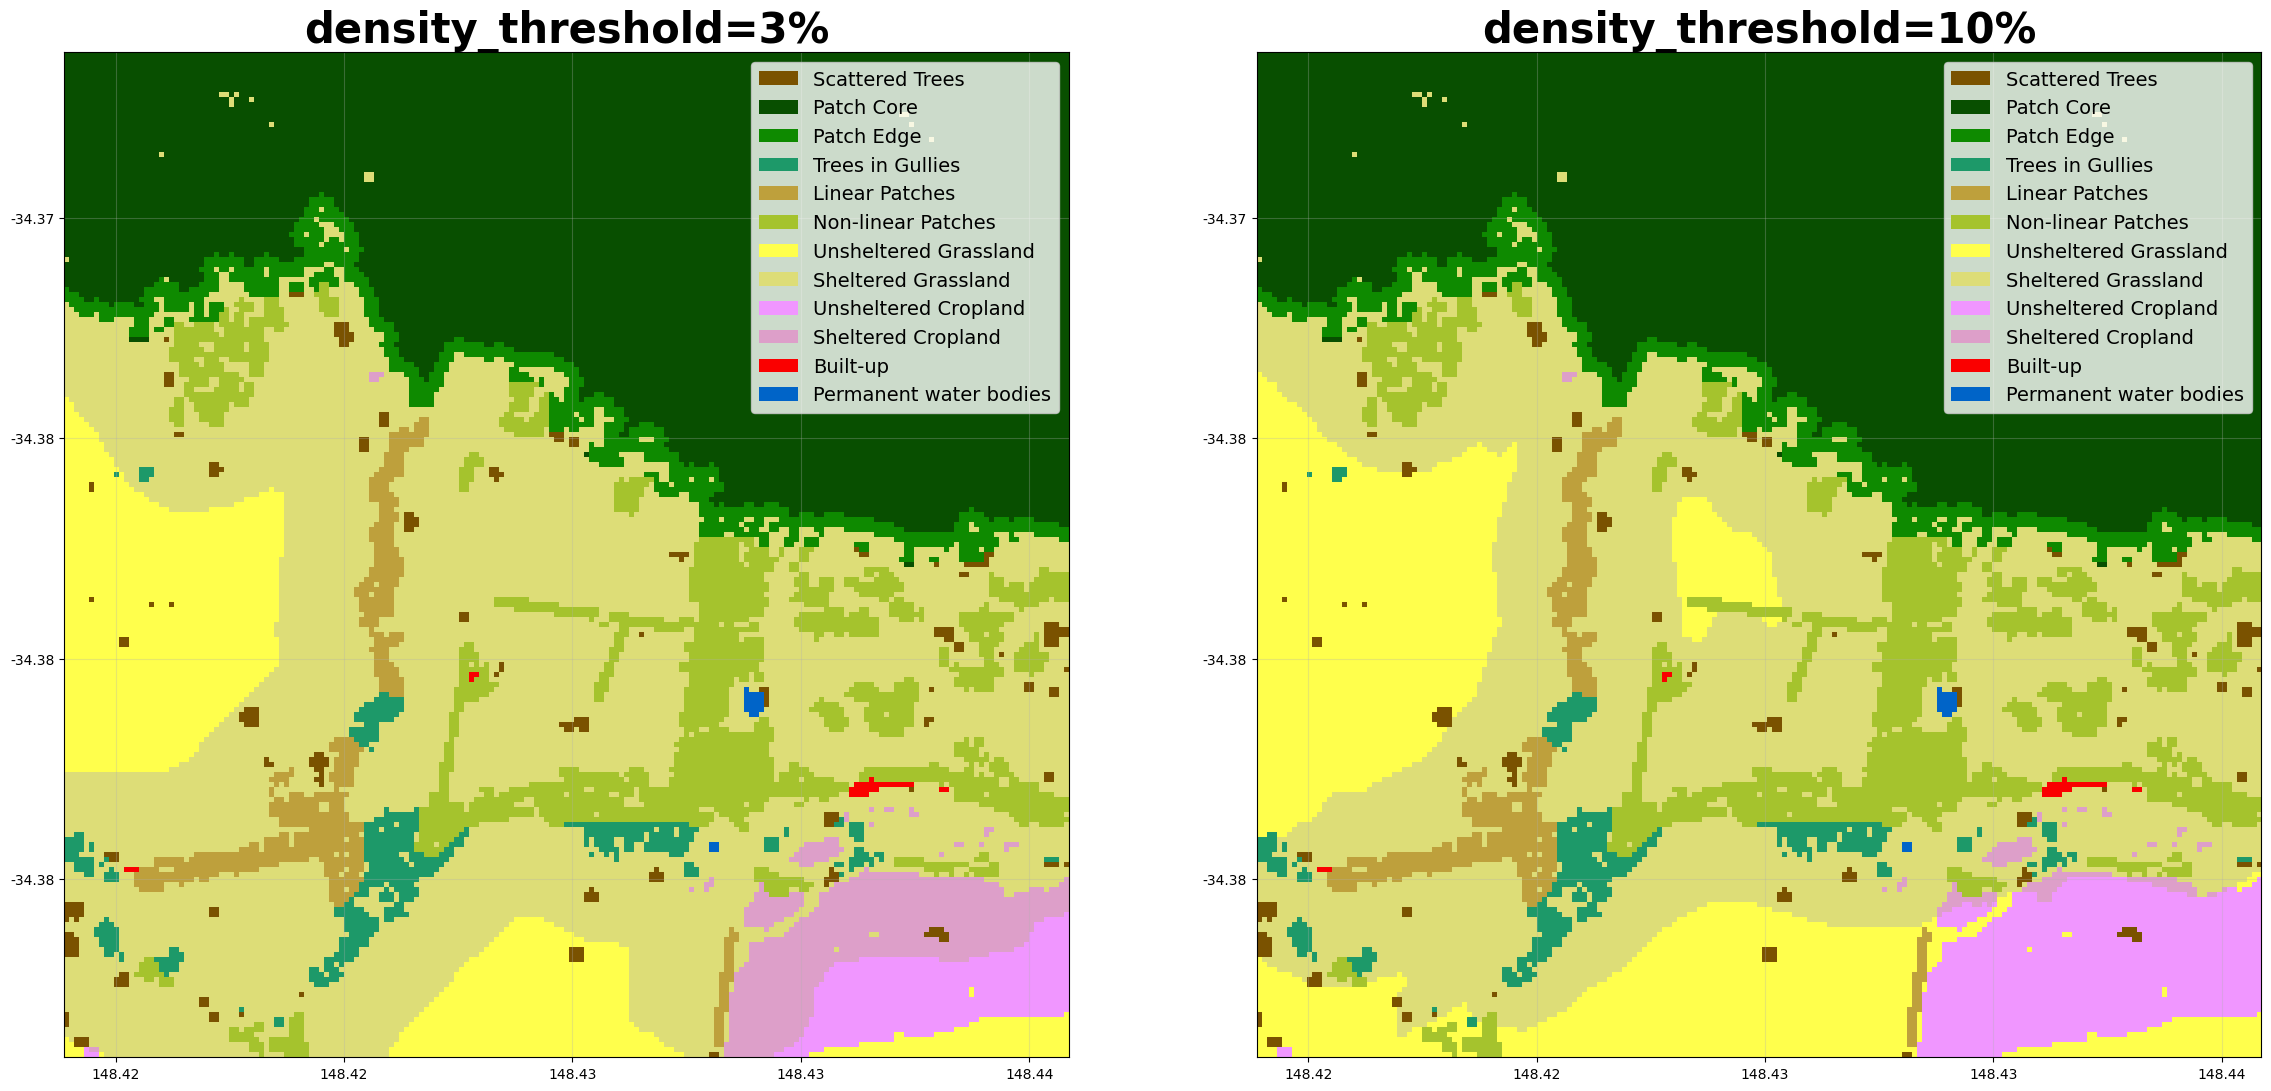

In [4]:
ds1 = shelter_categories(ds_linear, stub='density3', density_threshold=3)
ds2 = shelter_categories(ds_linear, stub='density10', density_threshold=10)
visualise_categories_sidebyside(
    ds1['shelter_categories'], ds2['shelter_categories'],
    colormap=shelter_categories_cmap, labels=shelter_categories_labels,
    title1="density_threshold=3%", title2="density_threshold=10%"
)

## Changing the wind_method

- **MOST_COMMON**: Only downwind shelter using the most common wind direction
- **WINDWARD**: Both downwind (full distance) and upwind (half distance) shelter
- **HAPPENED**: Shelter from any direction where winds exceeded the threshold
- **ANY**: Shelter from all 8 compass directions regardless of wind

Saved: ./wind_MOST_COMMON_shelter_categories.tif
Saved: ./wind_MOST_COMMON_shelter_distances.tif
Saved: ./wind_MOST_COMMON_shelter_categories.png
Saved: ./wind_WINDWARD_shelter_categories.tif
Saved: ./wind_WINDWARD_shelter_distances.tif
Saved: ./wind_WINDWARD_shelter_categories.png


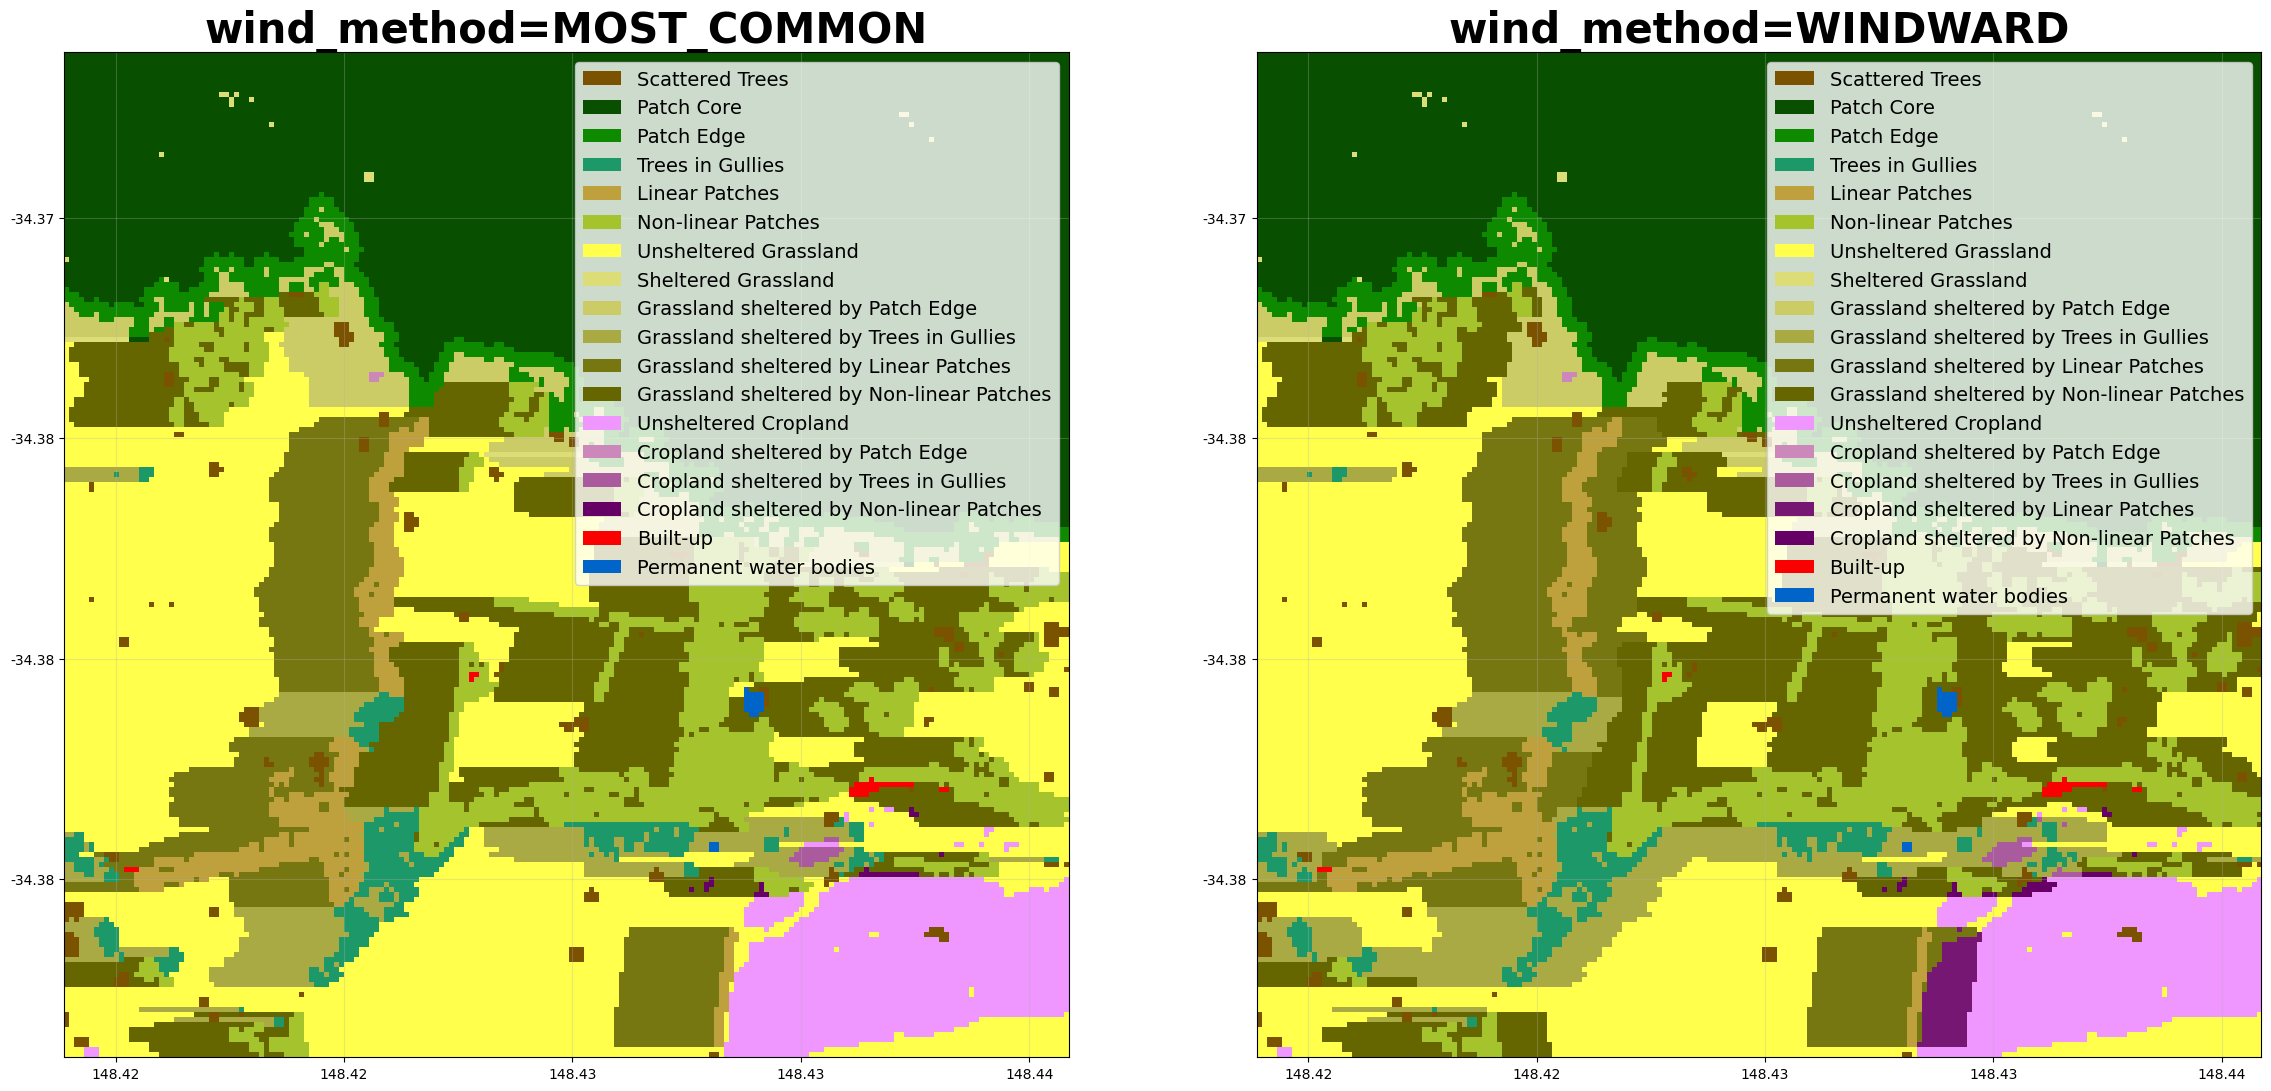

In [5]:
ds1 = shelter_categories(ds_linear, wind_data=wind_file, stub='wind_MOST_COMMON', wind_method='MOST_COMMON')
ds2 = shelter_categories(ds_linear, wind_data=wind_file, stub='wind_WINDWARD', wind_method='WINDWARD')
visualise_categories_sidebyside(
    ds1['shelter_categories'], ds2['shelter_categories'],
    colormap=shelter_categories_cmap, labels=shelter_categories_labels,
    title1="wind_method=MOST_COMMON", title2="wind_method=WINDWARD"
)

Saved: ./wind_HAPPENED_shelter_categories.tif
Saved: ./wind_HAPPENED_shelter_distances.tif
Saved: ./wind_HAPPENED_shelter_categories.png
Saved: ./wind_ANY_shelter_categories.tif
Saved: ./wind_ANY_shelter_distances.tif
Saved: ./wind_ANY_shelter_categories.png


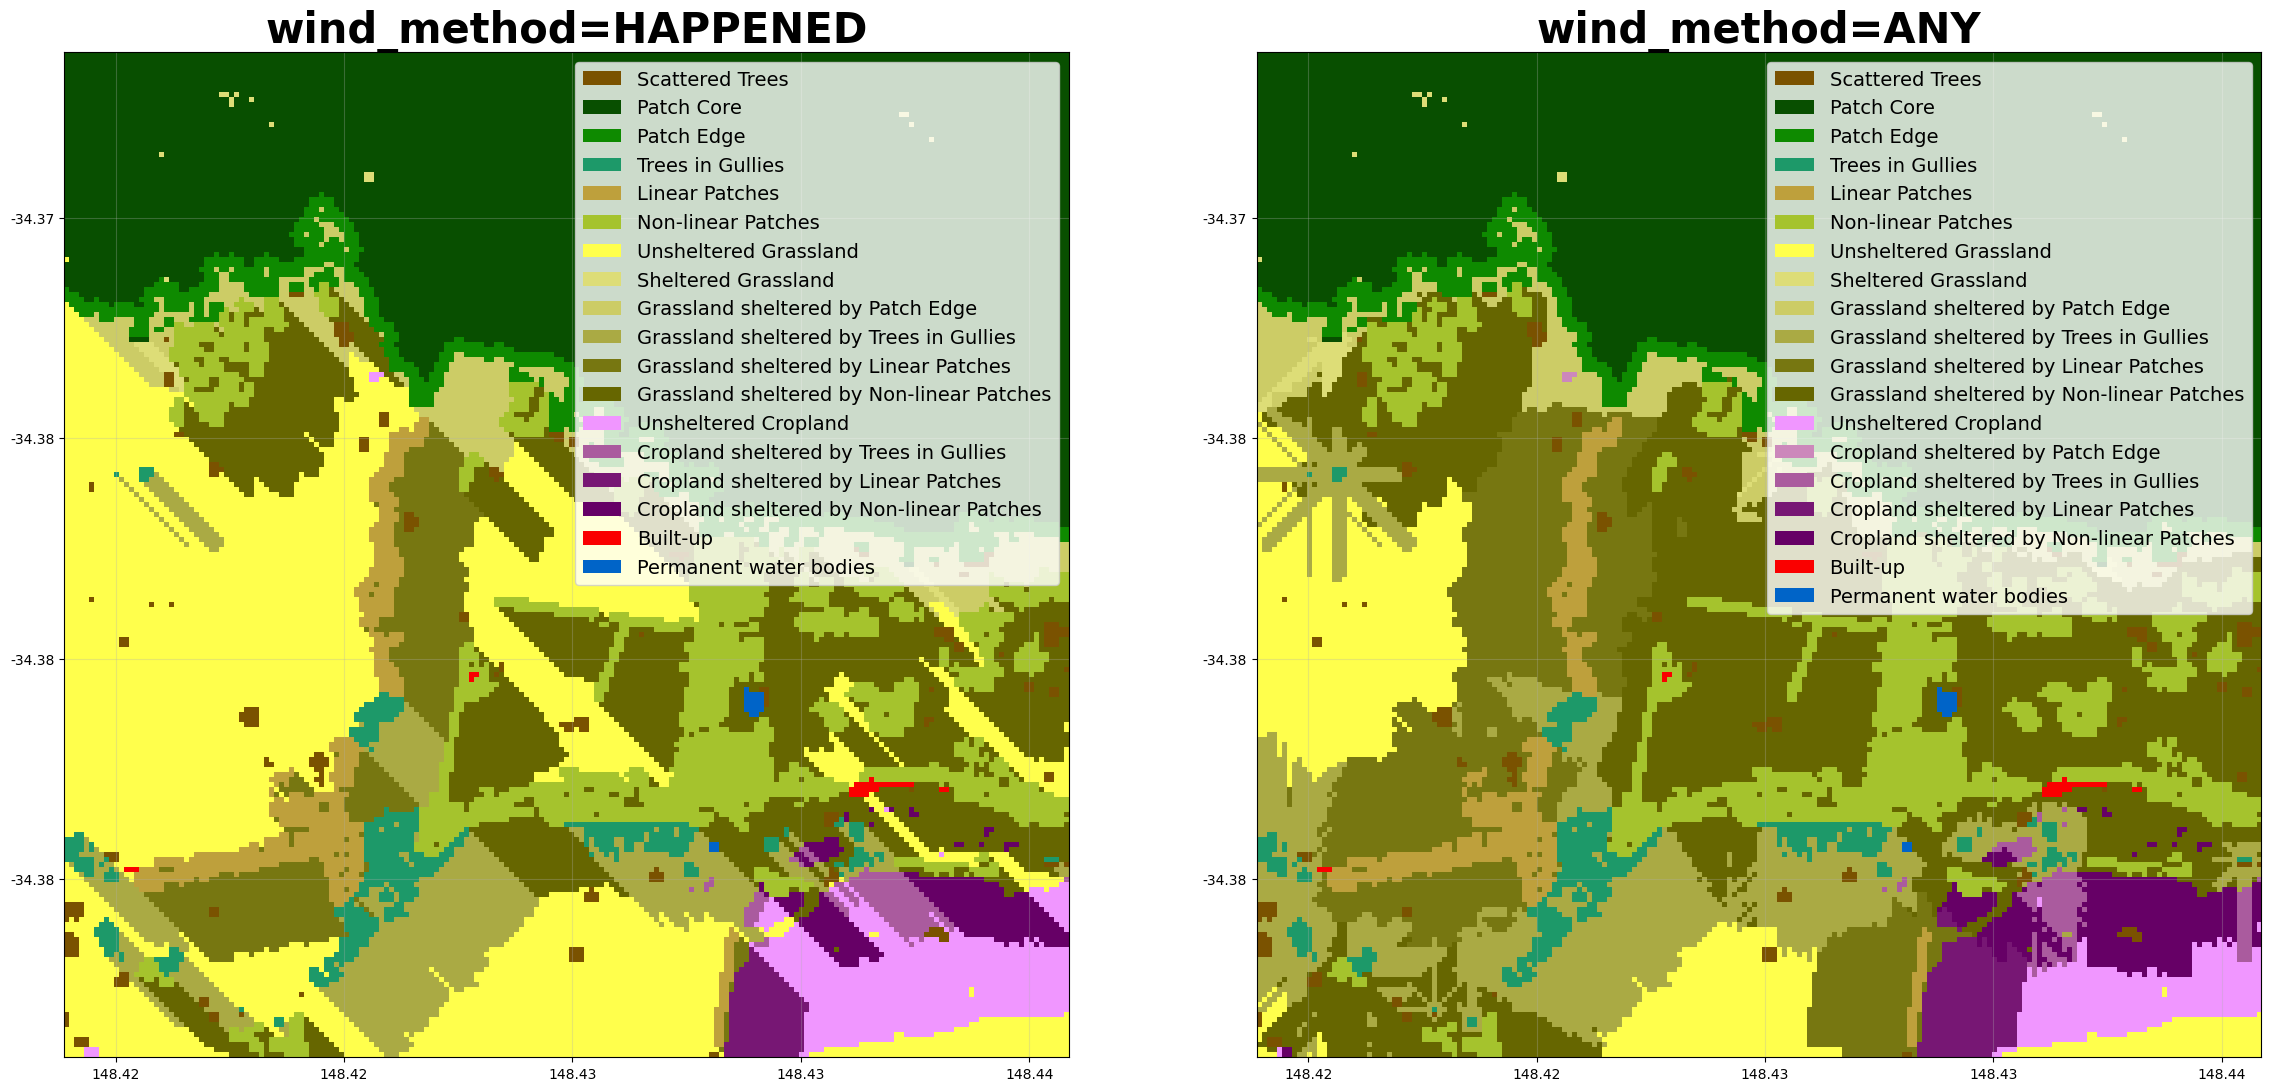

In [6]:
ds1 = shelter_categories(ds_linear, wind_data=wind_file, stub='wind_HAPPENED', wind_method='HAPPENED', wind_threshold=28)
ds2 = shelter_categories(ds_linear, wind_data=wind_file, stub='wind_ANY', wind_method='ANY')
visualise_categories_sidebyside(
    ds1['shelter_categories'], ds2['shelter_categories'],
    colormap=shelter_categories_cmap, labels=shelter_categories_labels,
    title1="wind_method=HAPPENED", title2="wind_method=ANY"
)

## MULTI_LAYER: All 8 Directions at Once

`wind_method='MULTI_LAYER'` computes shelter distances independently for all 8 compass directions
(clockwise: N, NE, E, SE, S, SW, W, NW) and saves them as an 8-band GeoTIFF.

In [7]:
ds_multi = shelter_categories(ds_linear, wind_method='MULTI_LAYER', stub='wind_MULTI_LAYER')
print("shelter_distances shape (direction × y × x):", ds_multi['shelter_distances'].shape)
print("Band order:", ds_multi['shelter_distances'].direction.values.tolist())

Saved: ./wind_MULTI_LAYER_shelter_N.tif
Saved: ./wind_MULTI_LAYER_shelter_NE.tif
Saved: ./wind_MULTI_LAYER_shelter_E.tif
Saved: ./wind_MULTI_LAYER_shelter_SE.tif
Saved: ./wind_MULTI_LAYER_shelter_S.tif
Saved: ./wind_MULTI_LAYER_shelter_SW.tif
Saved: ./wind_MULTI_LAYER_shelter_W.tif
Saved: ./wind_MULTI_LAYER_shelter_NW.tif
Saved: ./wind_MULTI_LAYER_shelter_categories.tif
shelter_distances shape (direction × y × x): (8, 201, 201)
Band order: ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']


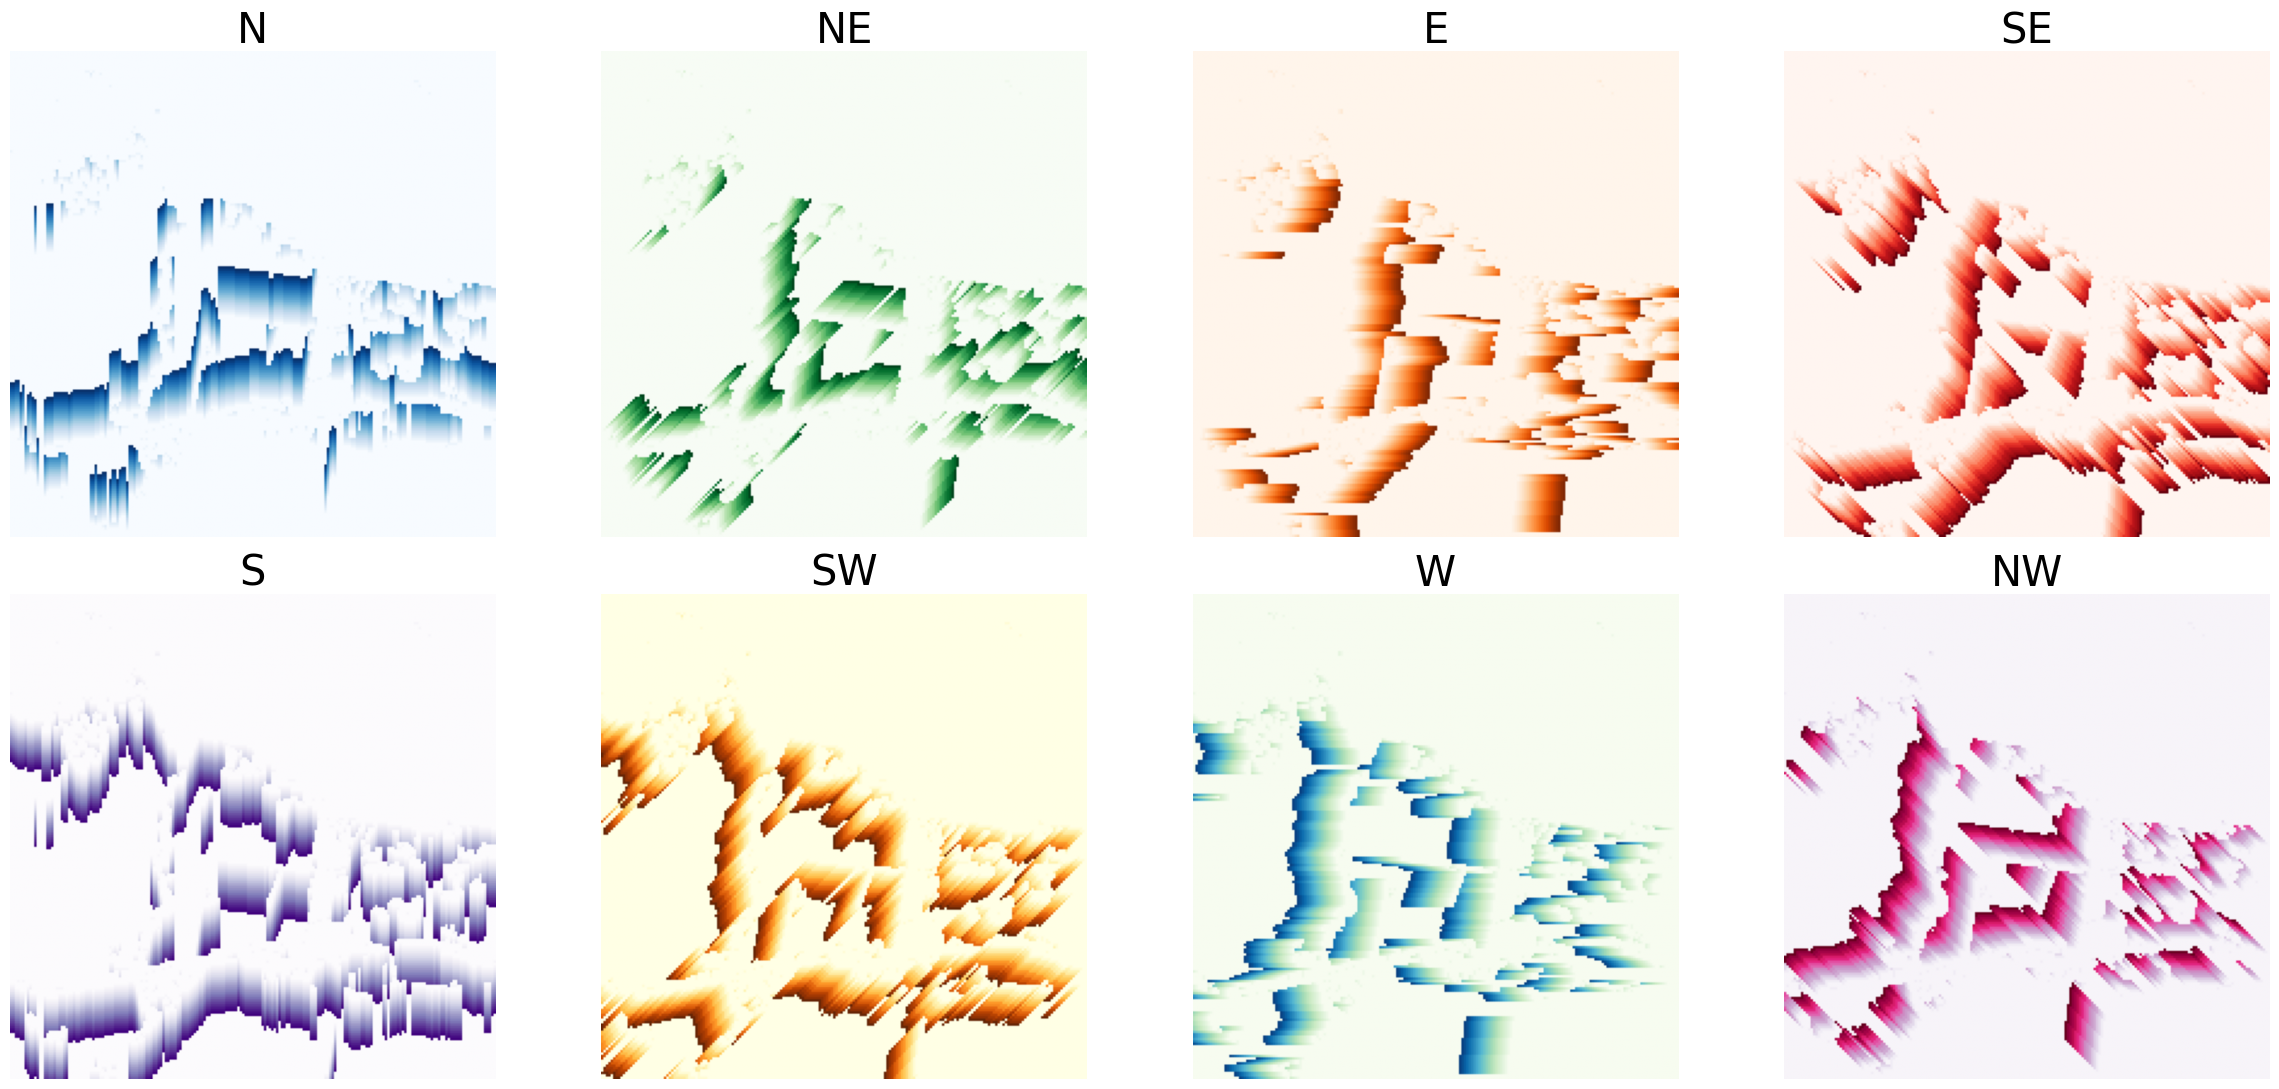

In [8]:
import matplotlib.pyplot as plt

directions = ds_multi['shelter_distances'].direction.values.tolist()
cmaps = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'YlOrBr', 'GnBu', 'PuRd']

_, axes = plt.subplots(2, 4, figsize=(24, 11))
for ax, direction, cmap_name in zip(axes.flat, directions, cmaps):
    band = ds_multi['shelter_distances'].sel(direction=direction)
    ax.imshow(band.values, cmap=cmap_name)
    ax.set_title(direction, fontsize=30)
    ax.axis('off')
plt.tight_layout()

## Changing the distance_threshold

The `distance_threshold` parameter defines how far from trees a pixel is still considered sheltered.
Units are either pixels (without height data) or tree heights (with height data).

In [ ]:
ds1 = shelter_categories(ds_linear, wind_data=wind_file, stub='distance10', distance_threshold=10)
ds2 = shelter_categories(ds_linear, wind_data=wind_file, stub='distance30', distance_threshold=30)
visualise_categories_sidebyside(
    ds1['shelter_categories'], ds2['shelter_categories'],
    colormap=shelter_categories_cmap, labels=shelter_categories_labels,
    title1="distance_threshold=10 pixels", title2="distance_threshold=30 pixels"
)

Saved: ./distance10_shelter_categories.tif
Saved: ./distance10_shelter_distances.tif
Saved: ./distance10_shelter_categories.png
Saved: ./distance30_shelter_categories.tif
Saved: ./distance30_shelter_distances.tif
Saved: ./distance30_shelter_categories.png


### Providing Tree Heights
If you provide a height tif then the distance_threshold represents the number of tree_heights, rather than the number of 10m pixels downwind from each tree.

In [ ]:
# Example height tif (Canopy Height Model)
chm = rxr.open_rasterio(height_file).isel(band=0).drop_vars('band')
p = chm.plot()
p.axes.set_title('Canopy Height Model')
p.axes.axis('off');

In [ ]:
# This comparison shows that some taller trees provide more shelter than the default, 
# whereas some shorter trees (like in the centre) provide less shelter than the default.
ds1 = shelter_categories(ds_linear, wind_data=wind_file, wind_method='MOST_COMMON', stub='default')  # distance threshold represents the number of pixels (10m each)
ds2 = shelter_categories(ds_linear, wind_data=wind_file, wind_method='MOST_COMMON', height_tif=height_file, stub='heights_provided', distance_threshold=15)  # distance_threshold represents the number of "tree_heights"
visualise_categories_sidebyside(
    ds1['shelter_categories'], ds2['shelter_categories'],
    colormap=shelter_categories_cmap, labels=shelter_categories_labels,
    title1="default", title2="Height tif"
)

## Changing the wind_threshold

The `wind_threshold` parameter sets the wind speed (km/h) used to determine dominant wind direction.
Only used when `wind_data` is provided.

In [ ]:
ds1 = shelter_categories(ds_linear, wind_data=wind_file, stub='wind_threshold10', wind_threshold=10)
ds2 = shelter_categories(ds_linear, wind_data=wind_file, stub='wind_threshold30', wind_threshold=30)
visualise_categories_sidebyside(
    ds1['shelter_categories'], ds2['shelter_categories'],
    colormap=shelter_categories_cmap, labels=shelter_categories_labels,
    title1="wind_threshold=10 km/h", title2="wind_threshold=30 km/h"
)

## Command Line Interface
You can also use the function from the command line with the same defaults and parameters.

In [ ]:
!python -m shelterbelts.indices.shelter_categories --help

In [ ]:
%%time
!python -m shelterbelts.indices.shelter_categories {linear_categories_file} --stub command_line_defaults

In [ ]:
!python -m shelterbelts.indices.shelter_categories {linear_categories_file} --wind_data {wind_file} --height_tif {height_file} --wind_method MOST_COMMON --distance_threshold 10 --stub command_line

### Cleanup
Remove the output files created by this notebook

In [ ]:
# !rm *.tif
# !rm *.png
# !rm *.xml  # These get generated if you load the tifs in QGIS